<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Impute Missing Values**


Estimated time needed: **30** minutes


In this lab, you will practice essential data wrangling techniques using the Stack Overflow survey dataset. The primary focus is on handling missing data and ensuring data quality. You will:

- **Load the Data:** Import the dataset into a DataFrame using the pandas library.

- **Clean the Data:** Identify and remove duplicate entries to maintain data integrity.

- **Handle Missing Values:** Detect missing values, impute them with appropriate strategies, and verify the imputation to create a complete and reliable dataset for analysis.

This lab equips you with the skills to effectively preprocess and clean real-world datasets, a crucial step in any data analysis project.


## Objectives


In this lab, you will perform the following:


-   Identify missing values in the dataset.

-   Apply techniques to impute missing values in the dataset.
  
-   Use suitable techniques to normalize data in the dataset.


-----


#### Install needed library


In [1]:
!pip install pandas

### Step 1: Import Required Libraries


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset Into a Dataframe


#### **Read Data**
<p>
The functions below will download the dataset into your browser:
</p>


In [3]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### Step 3. Finding and Removing Duplicates
##### Task 1: Identify duplicate rows in the dataset.


In [4]:
# Identifying duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
duplicates = df[df.duplicated(keep=False)]

print(f"Number of duplicated rows: {duplicate_count}")
duplicates.head()

Number of duplicated rows: 10

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


##### Task 2: Remove the duplicate rows from the dataframe.



In [5]:
# Remove duplicates by default keep the first occurrence and removes subsequent identical rows
df_clean = df.drop_duplicates()

# Verify the removal
duplicate_count_after = df_clean.duplicated().sum()
print(f"Number of duplicated rows after removal: {duplicate_count_after}")

# Compare the row counts
rows_before = len(df)
rows_after = len(df_clean)
rows_removed = rows_before - rows_after

# Reporting rows counts
print(f"Rows before: {rows_before}")
print(f"Rows after: {rows_after}")
print(f"Rows removed: {rows_removed}")
print(f"Duplicates after removal: {df_clean.duplicated().sum()}")

Number of duplicated rows after removal: 0
Rows before: 65447
Rows after: 65437
Rows removed: 10Duplicates after removal: 0

### Step 4: Finding Missing Values
##### Task 3: Find the missing values for all columns.


In [6]:
# Identifying missing values for all columns
missing_values = df_clean.isnull().sum()

# Calculating the percentage of missing values
missing_summary = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": df_clean.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary.head(10)

,Missing Values,Missing Percentage
AINextMuch less integrated,64289,98.245641
AINextLess integrated,63082,96.401119
AINextNo change,52939,80.900714
AINextMuch more integrated,51999,79.464217
EmbeddedAdmired,48704,74.428840
EmbeddedWantToWorkWith,47837,73.103901
EmbeddedHaveWorkedWith,43223,66.052845
ConvertedCompYearly,42002,64.186928
AIToolNot interested in Using,41023,62.690832
AINextMore integrated,41009,62.669438


##### Task 4: Find out how many rows are missing in the column RemoteWork.


In [7]:
# Missing rows for column RemoteWork
missing_remotework = df_clean["RemoteWork"].isnull().sum()
print(f"Missing values in RemoteWork: {missing_remotework}")

Missing values in RemoteWork: 10631

### Step 5. Imputing Missing Values
##### Task 5: Find the value counts for the column RemoteWork.


In [9]:
# Finding the missing values for RemoteWork
remote_work_counts = df_clean["RemoteWork"].value_counts()
print(remote_work_counts)

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

##### Task 6: Identify the most frequent (majority) value in the RemoteWork column.



In [10]:
# Finding the most frequent value in RemoteWork
majority_value = remote_work_counts.idxmax()
print(f"Most frequent RemoteWork value: {majority_value}")

Most frequent RemoteWork value: Hybrid (some remote, some in-person)

##### Task 7: Impute (replace) all the empty rows in the column RemoteWork with the majority value.



In [11]:
# Imputing missing values at RemoteWork column with the most frequent value
df_clean["RemoteWork"] = df_clean["RemoteWork"].fillna(majority_value)

##### Task 8: Check for any compensation-related columns and describe their distribution.



In [17]:
# Finding compensation related columns
compensation_columns = [
    col for col in df.columns
    if "Comp" in col
]

print(compensation_columns)

['CompTotal', 'AIComplex', 'ConvertedCompYearly']

In [20]:
# Describing the compensation-related columns
compensation_columns = ['CompTotal', 'ConvertedCompYearly']
df[compensation_columns].describe()

,CompTotal,ConvertedCompYearly
count,3.374000e+04,2.343500e+04
mean,2.963841e+145,8.615529e+04
std,5.444117e+147,1.867570e+05
min,0.000000e+00,1.000000e+00
25%,6.000000e+04,3.271200e+04
50%,1.100000e+05,6.500000e+04
75%,2.500000e+05,1.079715e+05
max,1.000000e+150,1.625660e+07


In [21]:
# Checking missing values
df[compensation_columns].isnull().sum()

CompTotal              31707
ConvertedCompYearly    42012
dtype: int64

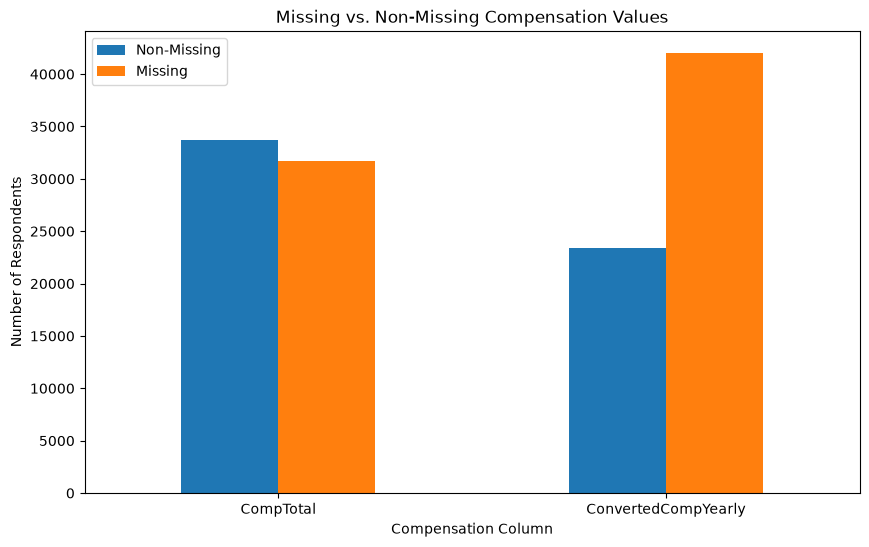

In [24]:
# Visualizing the distribution of missing values for compensation columns
compensation_summary = pd.DataFrame({
    "Non-Missing": df[compensation_columns].count(),
    "Missing": df[compensation_columns].isnull().sum()
})

compensation_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Missing vs. Non-Missing Compensation Values")
plt.xlabel("Compensation Column")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)

plt.show()

### Summary 


**In this lab, you focused on imputing missing values in the dataset.**

- Use the <code>pandas.read_csv()</code> function to load a dataset from a CSV file into a DataFrame.

- Download the dataset if it's not available online and specify the correct file path.



<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-09-27|1.1|Madhusudhan Moole|Updated lab|
|2024-09-26|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
